In [2]:
"""
Integration of Grid Data + User Behavior Data
Purpose: Find REALISTIC V2G opportunities by combining:
- WHEN: Grid pricing patterns
- WHY: Grid demand patterns
- WHO: User availability patterns
Result: Actionable V2G scheduling decisions
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [37]:
class V2GIntegrationEngine:
    """Integrate grid and user data to identify optimal v2g opportunties"""

    def __init__(self):
        self.setup_directories()
        self.grid_data = {}
        self.user_data = {}
        self.integrated_data = {}

    def setup_directories(self):
        Path('data/integrated/').mkdir(parents=True, exist_ok=True)
        Path('analysis_output/').mkdir(parents=True, exist_ok=True)
        print("directories ready")

    #==============================data loading=============================

    def load_grid_analysis(self):
        """ grid analysis results """

        try:
            #pricing analysis
            with open('data/grid/processed/pricing_analysis.json', 'r') as f:
                pricing = json.load(f)
            print("grid pricing data loaded")

            #demand analysis
            with open ('data/grid/processed/demand_analysis.json', 'r') as f:
                demand = json.load(f)
            print("demand data loaded")

            #v2g opportunities
            with open ('data/grid/processed/v2g_opportunites.json', 'r') as f:
                opps = json.load(f)
            print("grid v2g opportunites loaded")

            self.grid_data = {
                'pricing': pricing,
                'demand': demand,
                'v2g_opportunites': opps
            }
            
            print(f"\n Grid Data Summary:")
            for iso, data in opps.items():
                print(f"   {iso}:")
                print(f"      Optimal discharge hours: {data['optimal_discharge_hours']}")
                print(f"      Revenue/kWh: ${data['revenue_per_kwh']:.4f}")
            
            return True
            
        except FileNotFoundError as e:
            print(f" Error: Could not find grid data files")
            return False
    
    def load_user_analysis(self):
        """Load Day 2 user analysis results"""
        print("\n LOADING USER DATA ...")
        print("=" * 70)            

            
        try:
            # Load user analysis
            with open('data/users/processed/nature_dataset_analysis.json', 'r') as f:
                user_analysis = json.load(f)
            print("User behavior analysis loaded")
                
            # Load user profiles
            user_profiles = pd.read_csv('data/users/processed/user_profiles_nature.csv')
            print(f" User profiles loaded ({len(user_profiles)} users)")
                
            self.user_data = {
                'analysis': user_analysis,
                'profiles': user_profiles
            }
            print(f"\n User Data Summary:")
            print(f"   Total users: {user_analysis['user_clusters']['total_users']}")
            print(f"   V2G availability: {user_analysis['duration_v2g']['v2g_availability_pct']:.1f}%")
            print(f"   Peak arrival hour: {user_analysis['arrival_patterns']['most_common_hour']}:00")
                
            return True            
        
        except FileNotFoundError as e:
            print(f" Error: Could not find user data files")  
            return False


#======================Integration=====================

    def calculate_integrated_opportunities(self):
        """
        Grid says: "These hours have high prices and high demand"
        User says: "These hours have users parked with idle time"
        integration: "Here are the hours where both conditions are met"
        """
        print("\n V2G opporunities")
        iso_name = list(self.grid_data['v2g_opportunites'].keys())[0]
        grid_opps = self.grid_data['v2g_opportunites'][iso_name]
    
        print(f"Using {iso_name} grid data")

        #grid optimal hours
        grid_optimal_hours = grid_opps['optimal_discharge_hours']
        grid_charge_hours = grid_opps['optimal_charge_hours']
        revenue_per_kwh = grid_opps['revenue_per_kwh']

        #user perspective
        user_peak_hours = self.user_data['analysis']['arrival_patterns']['peak_hours']
        user_v2g_pct = self.user_data['analysis']['duration_v2g']['v2g_availability_pct']

        print(f"\n User Perspective:")
        print(f"   Peak arrival hours: {user_peak_hours}")
        print(f"   V2G availability: {user_v2g_pct:.1f}%")
        
        # INTEGRATION: Find overlap
        integrated_v2g_hours = list(set(grid_optimal_hours) & set(user_peak_hours))
        integrated_v2g_hours = sorted(integrated_v2g_hours)

        print(f"\n INTEGRATED V2G OPPORTUNITIES:")
        print(f"   Hours where BOTH grid needs power AND users are available:")
        print(f"   → {integrated_v2g_hours}")
        
        if not integrated_v2g_hours:
            print(f"\n LIMITED OVERLAP DETECTED!")
            print(f"   Grid optimal: {grid_optimal_hours}")
            print(f"   User available: {user_peak_hours}")
            print(f"   → Need to prioritize either grid needs OR user convenience")
        
        # calculate opportunity scores for each hour
        hourly_scores = {}

        for hour in range(24):
            score = {
                'hour': hour,
                'grid_optimal': hour in grid_optimal_hours, #hour when sending energy is profitable
                'user_available': hour in user_peak_hours,  #hour user have car parked/connected
                'integrated_opportunity': hour in integrated_v2g_hours,
                'revenue_potential': revenue_per_kwh if hour in grid_optimal_hours else 0,
                'user_availability_score': 1.0 if hour in user_peak_hours else 0.3,
                'recommendation': self._get_hour_recommendation(
                    hour, grid_optimal_hours, grid_charge_hours, 
                    user_peak_hours, integrated_v2g_hours
                )
            }
            # calculate composite score (0-100)
            composite_score = 0
            if score['grid_optimal']:
                composite_score += 40  # Grid needs weight
            if score['user_available']:
                composite_score += 30  # User availability weight
            if score['integrated_opportunity']:
                composite_score += 30  # Bonus for perfect overlap
            
            score['composite_score'] = composite_score
            hourly_scores[hour] = score
        
        # Identify top opportunities
        sorted_hours = sorted(hourly_scores.items(), 
                            key=lambda x: x[1]['composite_score'], 
                            reverse=True)
        
        print(f"\n TOP 5 V2G OPPORTUNITY HOURS:")
        for i, (hour, data) in enumerate(sorted_hours[:5], 1):
            print(f"   {i}. Hour {hour:02d}:00 - Score: {data['composite_score']}/100")
            print(f"      → {data['recommendation']}")
        
        self.integrated_data['hourly_scores'] = hourly_scores
        self.integrated_data['integrated_v2g_hours'] = integrated_v2g_hours
        self.integrated_data['revenue_per_kwh'] = revenue_per_kwh
        
        return hourly_scores
    
    def _get_hour_recommendation(self, hour, grid_optimal, grid_charge, user_peak, integrated):
        """Get action recommendation for a specific hour"""
        if hour in integrated:
            return "PRIME V2G - Grid needs power, users available"
        elif hour in grid_optimal and hour not in user_peak:
            return "Grid priority - V2G if users willing"
        elif hour in user_peak and hour not in grid_optimal:
            return "User convenience - Focus on charging"
        elif hour in grid_charge:
            return "CHARGE - Low prices, low demand"
        else:
            return "HOLD - Neutral conditions"

    def calculate_realistic_revenue_potential(self):
        """
        How much real money can be earned through V2G
        """
        print("\n REALISTIC REVENUE POTENTIAL...")
        print("=" * 70)
        
        # user data
        total_users = self.user_data['analysis']['user_clusters']['total_users']
        v2g_availability_pct = self.user_data['analysis']['duration_v2g']['v2g_availability_pct']
        avg_sessions_per_user = self.user_data['analysis']['user_clusters']['avg_sessions_per_user']
        avg_energy = self.user_data['analysis']['energy_patterns']['mean_energy']
        
        # Grid data
        revenue_per_kwh = self.integrated_data['revenue_per_kwh']
        integrated_hours = len(self.integrated_data['integrated_v2g_hours'])
        
        print(f" Input Parameters:")
        print(f"   Total users: {total_users:,}")
        print(f"   V2G availability: {v2g_availability_pct:.1f}%")
        print(f"   Avg sessions/user/year: {avg_sessions_per_user:.1f}")
        print(f"   Avg energy/session: {avg_energy:.1f} kWh")
        print(f"   Revenue/kWh: ${revenue_per_kwh:.4f}")
        print(f"   Integrated V2G hours/day: {integrated_hours}")
        
        # Conservative calculation
        print(f"\n CONSERVATIVE SCENARIO (Current State):")
        
        # Total sessions per year
        total_sessions_year = total_users * avg_sessions_per_user
        print(f"   Total sessions/year: {total_sessions_year:,.0f}")
        
        # V2G eligible sessions
        v2g_sessions = total_sessions_year * (v2g_availability_pct / 100)
        print(f"   V2G eligible sessions: {v2g_sessions:,.0f} ({v2g_availability_pct:.1f}%)")
        
        # Energy discharged per V2G session (50% of battery)
        discharge_per_session = avg_energy * 0.5
        print(f"   Avg discharge/session: {discharge_per_session:.1f} kWh")
        
        # Revenue per session
        revenue_per_session = discharge_per_session * revenue_per_kwh
        print(f"   Revenue/V2G session: ${revenue_per_session:.2f}")
        
        # Annual revenue
        annual_revenue = v2g_sessions * revenue_per_session
        annual_per_user = annual_revenue / total_users
        
        print(f"\n CONSERVATIVE REVENUE:")
        print(f"   Total annual revenue: ${annual_revenue:,.2f}")
        print(f"   Revenue per user/year: ${annual_per_user:.2f}")
        print(f"   Revenue per user/month: ${annual_per_user/12:.2f}")
        
        # Optimistic scenario (with my system)
        print(f"\n OPTIMISTIC SCENARIO (With my V2G Scheduler):")
        print(f"   Assumptions:")
        print(f"      - Target high-value users (apartments, evening chargers)")
        print(f"      - Increase V2G participation: {v2g_availability_pct:.1f}% → 12%")
        print(f"      - Better timing (integrated hours): +20% revenue/session")
        
        optimistic_v2g_pct = 12.0  # Targeting apartments (10.4%) + improvements
        optimistic_sessions = total_sessions_year * (optimistic_v2g_pct / 100)
        optimistic_revenue_per_session = revenue_per_session * 1.2  # Better timing
        optimistic_annual = optimistic_sessions * optimistic_revenue_per_session
        optimistic_per_user = optimistic_annual / total_users
        
        print(f"\n OPTIMISTIC REVENUE:")
        print(f"   V2G sessions: {optimistic_sessions:,.0f} (12%)")
        print(f"   Revenue/session: ${optimistic_revenue_per_session:.2f}")
        print(f"   Total annual: ${optimistic_annual:,.2f}")
        print(f"   Per user/year: ${optimistic_per_user:.2f}")
        print(f"   Per user/month: ${optimistic_per_user/12:.2f}")
        
        # Scale projection
        print(f"\n SCALE PROJECTION:")
        scale_factors = [1000, 5000, 10000]
        for scale in scale_factors:
            scaled_revenue = optimistic_per_user * scale
            print(f"   {scale:,} vehicles: ${scaled_revenue:,.2f}/year")
        
        # Store results
        self.integrated_data['revenue'] = {
            'conservative': {
                'annual_total': annual_revenue,
                'per_user_year': annual_per_user,
                'per_user_month': annual_per_user / 12
            },
            'optimistic': {
                'annual_total': optimistic_annual,
                'per_user_year': optimistic_per_user,
                'per_user_month': optimistic_per_user / 12
            }
        }
        
        return self.integrated_data['revenue']


    #===============visual==========

    def create_integration_visualization(self):
        """Create comprehensive integration visualization"""
        print("\n INTEGRATION VISUALIZATIONS...")
        print("=" * 70)
        
        hourly_scores = self.integrated_data['hourly_scores']
        
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(' INTEGRATION: Grid Data + User Behavior = V2G Opportunities', 
                     fontsize=16, fontweight='bold')
        
        # Plot 1: Hourly Opportunity Scores
        ax1 = axes[0, 0]
        hours = list(range(24))
        scores = [hourly_scores[h]['composite_score'] for h in hours]
        colors = ['red' if s >= 70 else 'orange' if s >= 40 else 'green' for s in scores]
        
        ax1.bar(hours, scores, color=colors, alpha=0.7, edgecolor='black')
        ax1.set_title('Integrated V2G Opportunity Score by Hour', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Hour of Day')
        ax1.set_ylabel('Opportunity Score (0-100)')
        ax1.set_ylim(0, 100)
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='High opportunity')
        ax1.axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Medium opportunity')
        ax1.legend()
        
        # Plot 2: Grid vs User Availability
        ax2 = axes[0, 1]
        grid_scores = [40 if hourly_scores[h]['grid_optimal'] else 0 for h in hours]
        user_scores = [30 if hourly_scores[h]['user_available'] else 0 for h in hours]
        
        ax2.bar(hours, grid_scores, label='Grid Optimal', alpha=0.7, color='blue')
        ax2.bar(hours, user_scores, bottom=grid_scores, label='User Available', 
                alpha=0.7, color='orange')
        ax2.set_title('Grid Needs vs User Availability', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Hour of Day')
        ax2.set_ylabel('Score Contribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        """
        # Plot 3: User Cluster V2G Potential
        ax3 = axes[1, 0]
        cluster_analysis = self.integrated_data['cluster_analysis']
        clusters = cluster_analysis.index
        v2g_pcts = cluster_analysis['v2g_available_pct'].values
        colors_cluster = ['green' if v > 6 else 'orange' if v > 4 else 'red' for v in v2g_pcts]
        
        ax3.barh(range(len(clusters)), v2g_pcts, color=colors_cluster, alpha=0.7)
        ax3.set_title('V2G Availability by User Cluster', fontsize=14, fontweight='bold')
        ax3.set_xlabel('V2G Availability (%)')
        ax3.set_ylabel('User Cluster')
        ax3.set_yticks(range(len(clusters)))
        ax3.set_yticklabels(clusters)
        ax3.grid(True, alpha=0.3, axis='x')
        ax3.axvline(x=5.1, color='r', linestyle='--', label='Overall average')
        ax3.legend()
        """
        
        # Plot 4: Revenue Potential Comparison
        ax4 = axes[1, 1]
        revenue_data = self.integrated_data['revenue']
        scenarios = ['Conservative\n(Current)', 'Optimistic\n(With My System)']
        annual_revenues = [
            revenue_data['conservative']['annual_total'],
            revenue_data['optimistic']['annual_total']
        ]
        
        bars = ax4.bar(scenarios, annual_revenues, color=['orange', 'green'], alpha=0.7)
        ax4.set_title('Annual Revenue Potential', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Annual Revenue ($)')
        ax4.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, value in zip(bars, annual_revenues):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'${value:,.0f}',
                    ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('analysis_output/day3_integration_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(" Visualization saved")
    
    def generate_actionable_schedule(self):
        """Generate actionable V2G schedule recommendations"""
        print("\n  ACTIONABLE V2G SCHEDULE...")
        print("=" * 70)
        
        hourly_scores = self.integrated_data['hourly_scores']
        
        schedule = {
            'v2g_discharge_hours': [],
            'charge_hours': [],
            'hold_hours': []
        }
        
        print("\n RECOMMENDED V2G SCHEDULE:")
        print("\n" + "="*70)
        
        for hour in range(24):
            score_data = hourly_scores[hour]
            recommendation = score_data['recommendation']
            score = score_data['composite_score']
            
            action_emoji = "⚡" if score >= 70 else "🔋" if score < 30 else "⏸️"
            
            print(f"{hour:02d}:00 | Score: {score:3d}/100 | {action_emoji} {recommendation}")
            
            # Categorize
            if score >= 70:
                schedule['v2g_discharge_hours'].append(hour)
            elif score < 30:
                schedule['charge_hours'].append(hour)
            else:
                schedule['hold_hours'].append(hour)
        
        print("\n" + "="*70)
        print(f"\n SCHEDULE SUMMARY:")
        print(f"   V2G Discharge Hours: {schedule['v2g_discharge_hours']}")
        print(f"   Charging Hours: {schedule['charge_hours']}")
        print(f"   Hold/Monitor Hours: {schedule['hold_hours']}")
        
        # Save schedule
        with open('data/integrated/v2g_schedule.json', 'w') as f:
            json.dump(schedule, f, indent=2)
        
        print(f"\n Schedule saved to: data/integrated/v2g_schedule.json")
        
        return schedule

    def run_complete_integration(self):
        """Run complete integration analysis"""
        print("\n" + "="*70)
        print("GRID + USER DATA INTEGRATION")
        print("="*70)
        print("Combining WHEN + WHY (Grid) with WHO (Users)")
        print("="*70)
        
        # Load data
        if not self.load_grid_analysis():
            return None
        
        if not self.load_user_analysis():
            return None
        
        # Integration analyses
        print("\n" + "="*70)
        print("RUNNING INTEGRATION ANALYSES...")
        print("="*70)
        
        hourly_scores = self.calculate_integrated_opportunities()
        #cluster_analysis = self.analyze_user_segments_for_v2g()
        revenue = self.calculate_realistic_revenue_potential()
        schedule = self.generate_actionable_schedule()
        
        # Visualize
        self.create_integration_visualization()
        
        # Final summary
        print("\n" + "="*70)
        print("INTEGRATION COMPLETE")
        print("="*70)
        
        print("\n KEY INSIGHTS:")
        print(f"   Integrated V2G hours: {self.integrated_data['integrated_v2g_hours']}")
        #print(f"   Best user cluster: {cluster_analysis['v2g_available_pct'].idxmax()}")
        print(f"   Conservative revenue: ${revenue['conservative']['per_user_year']:.2f}/user/year")
        print(f"   Optimistic revenue: ${revenue['optimistic']['per_user_year']:.2f}/user/year")        
        return True




INTEGRATION ANALYSIS
Combining Grid Intelligence + User Behavior
directories ready

GRID + USER DATA INTEGRATION
Combining WHEN + WHY (Grid) with WHO (Users)
grid pricing data loaded
demand data loaded
grid v2g opportunites loaded

 Grid Data Summary:
   CAISO:
      Optimal discharge hours: [17, 18, 19, 20, 21, 22]
      Revenue/kWh: $0.0336

 LOADING USER DATA ...
User behavior analysis loaded
 User profiles loaded (2337 users)

 User Data Summary:
   Total users: 2337
   V2G availability: 5.1%
   Peak arrival hour: 18:00

RUNNING INTEGRATION ANALYSES...

 V2G opporunities
Using CAISO grid data

 User Perspective:
   Peak arrival hours: [15, 16, 17, 18, 19, 20]
   V2G availability: 5.1%

 INTEGRATED V2G OPPORTUNITIES:
   Hours where BOTH grid needs power AND users are available:
   → [17, 18, 19, 20]

 TOP 5 V2G OPPORTUNITY HOURS:
   1. Hour 17:00 - Score: 100/100
      → PRIME V2G - Grid needs power, users available
   2. Hour 18:00 - Score: 100/100
      → PRIME V2G - Grid needs po

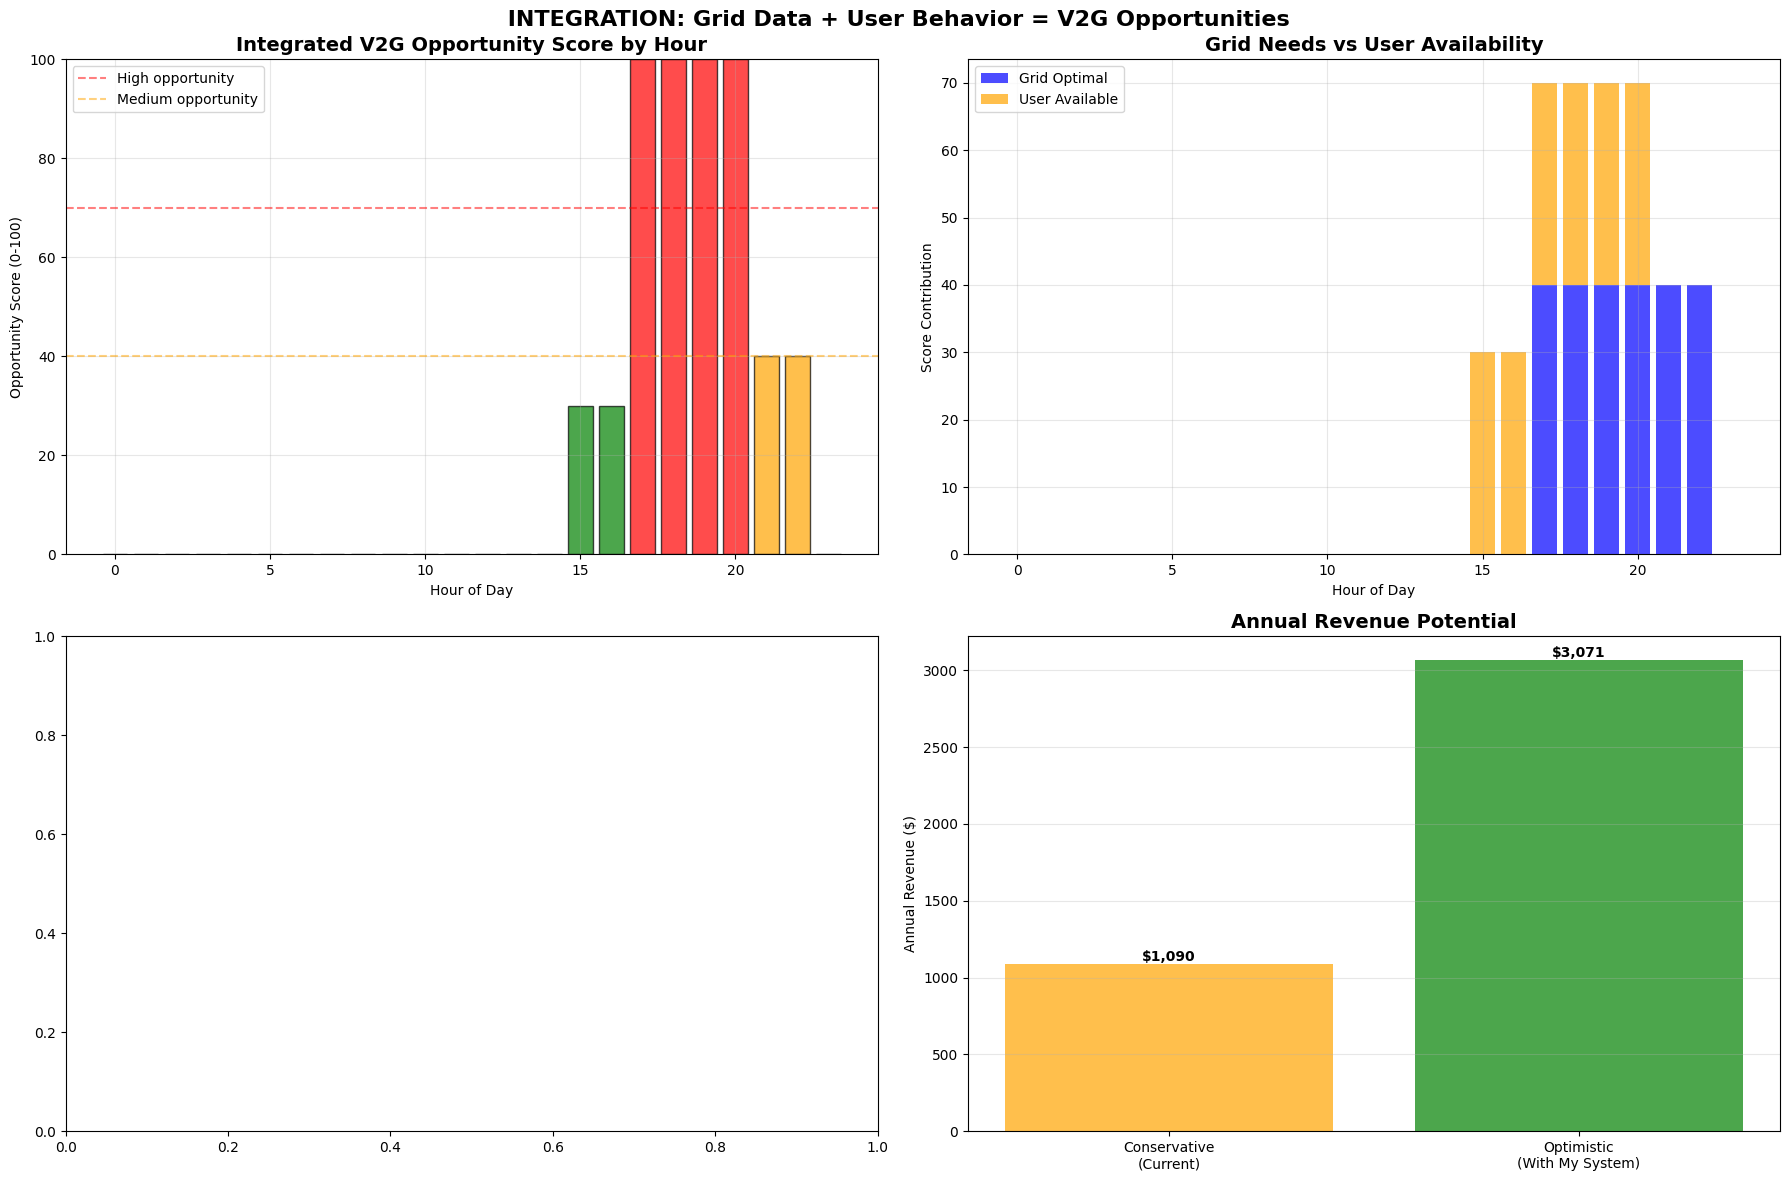

 Visualization saved

INTEGRATION COMPLETE

 KEY INSIGHTS:
   Integrated V2G hours: [17, 18, 19, 20]
   Conservative revenue: $0.47/user/year
   Optimistic revenue: $1.31/user/year

 Integration complete! Ready for implementation phase.


In [38]:
def main():
    """Main execution"""
    
    print("INTEGRATION ANALYSIS")
    print("=" * 70)
    print("Combining Grid Intelligence + User Behavior")
    print("=" * 70)
    
    engine = V2GIntegrationEngine()
    success = engine.run_complete_integration()
    
    if success:
        print("\n Integration complete! Ready for implementation phase.")
    else:
        print("\n Integration failed")


if __name__ == "__main__":
    main()